In [1]:
import os
import argparse


import sys

sys.path.append("../src")
sys.path.append("../config")

from utils import number_split, create_mix, appendMetrics

from sampling_numbers import HateSpeech_DICT, SHAC_DICT, CD_DICT

from pathlib import Path
import itertools
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import random
from sklearn import metrics
import pickle
from sklearn.metrics import precision_recall_fscore_support
import warnings

from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from process_CD import load_cd
from process_SHAC import load_process_SHAC

warnings.simplefilter("ignore")


# Load and Split

In [2]:
# df_dynGen = load_HateSpeech_dynGen()
# df_wsf = load_HateSpeech_wsf()

In [3]:
# df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-3636-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_dynGen.csv")
# df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-3636-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_wsf.csv")


# df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_dynGen.csv")
# df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_wsf.csv")

# df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_dynGen.csv")
# df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added_df_wsf.csv")


# df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_dynGen.csv")
# df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_wsf.csv")



# df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_dynGen.csv")
# df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_wsf.csv")



df_dynGen = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_dynGen.csv")
df_wsf = pd.read_csv("/bime-munin/xiruod/llama2_HateSpeech/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added_df_wsf.csv")


n_test=200
c = HateSpeech_DICT[f"c_n200_566"]


p_pos_train_z0_ls = HateSpeech_DICT["Run-2"]["p_pos_train_z0_ls"]
p_pos_train_z1_ls = HateSpeech_DICT["Run-2"]["p_pos_train_z1_ls"]
p_mix_z1_ls = HateSpeech_DICT["Run-2"]["p_mix_z1_ls"]
    
z_Categories = ["dynGen","wsf"]
label = "label_binary"
split_label = "label_binary"
n_zCats = len(z_Categories)
txt_col = "text"
domain_col = "dfSource"
df0 = df_dynGen
df1 = df_wsf

In [4]:
# df_shac = load_process_SHAC(replaceNA="all")

# df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
# df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)


In [5]:
df_shac = load_process_SHAC(replaceNA="all")

df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)


In [2]:
# df_avh = pd.read_csv("/bime-munin/xiruod/llama2_CD/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added_df_avh.csv")
# df_r56 = pd.read_csv("/bime-munin/xiruod/llama2_CD/n200/Inferences/inference_set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added_df_r56.csv")

# df_avh = pd.read_csv("/bime-munin/xiruod/llama2_CD/n200/Inferences_ReverseSource/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added_df_avh.csv")
# df_r56 = pd.read_csv("/bime-munin/xiruod/llama2_CD/n200/Inferences_ReverseSource/inference_set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added_df_r56.csv")


# df_avh = pd.read_csv("/bime-munin/xiruod/roberta-base_CD/n200/Inferences_ReverseSource/inference_set-6621-epoch3-lambda1_1.0-lambda2_1.0-added_df_avh.csv")
# df_r56 = pd.read_csv("/bime-munin/xiruod/roberta-base_CD/n200/Inferences_ReverseSource/inference_set-6621-epoch3-lambda1_1.0-lambda2_1.0-added_df_r56.csv")

df_avh = pd.read_csv("/bime-munin/xiruod/roberta-base_CD/n200/Inferences/inference_set-566-epoch3-lambda1_1.0-lambda2_1.0-added_df_avh.csv")
df_r56 = pd.read_csv("/bime-munin/xiruod/roberta-base_CD/n200/Inferences/inference_set-566-epoch3-lambda1_1.0-lambda2_1.0-added_df_r56.csv")


txt_col = "text"

z_Categories = ["avh","r56"] 

n_test=200
c = CD_DICT[f"c_n200_566"]


p_pos_train_z0_ls = CD_DICT["Run-1"]["p_pos_train_z0_ls"]
p_pos_train_z1_ls = CD_DICT["Run-1"]["p_pos_train_z1_ls"]
p_mix_z1_ls = CD_DICT["Run-1"]["p_mix_z1_ls"]
    
label = "label_binary"
n_zCats = len(z_Categories)
txt_col = "text"
domain_col = "dfSource"
df0 = df_avh
df1 = df_r56

In [3]:

############ Diff Out Dataset used in LoRA Fine-Tuning
dfs_used = create_mix(
    df0=df0,
    df1=df1,
    target=label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

In [4]:
c

{'n_train': 800,
 'n_test': 200,
 'n_z0_pos_train': 40,
 'n_z0_neg_train': 360,
 'n_z0_pos_test': 30,
 'n_z0_neg_test': 70,
 'n_z1_pos_train': 200,
 'n_z1_neg_train': 200,
 'n_z1_pos_test': 30,
 'n_z1_neg_test': 70,
 'mix_param_dict': {'p_pos_train_z0': 0.1,
  'p_pos_train_z1': 0.5,
  'p_pos_train': 0.3,
  'p_pos_test': 0.3,
  'p_mix_z0': 0.5,
  'p_mix_z1': 0.5,
  'alpha_train': 5.0,
  'alpha_test': 1.0,
  'p_pos_test_z0': 0.3,
  'p_pos_test_z1': 0.3,
  'C_y': 0.3,
  'C_z': 0.5,
  'C_y_test': 0.3}}

# Prepare for Iterations

In [5]:
train_test_ratio = 4

df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


############  Get Split Configs & Further Limit Sampling Set, if necessary

# numvals = 1023
# base = 1.1
# alpha_test_ls = np.power(base, np.arange(numvals)) / np.power(base, numvals // 2)
alpha_test_ls = np.float_power(10, np.linspace(start=-2, stop=2, num=40))


valid_full_settings = []
for combination in itertools.product(
    p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls, alpha_test_ls
):

    number_setting = number_split(
        p_pos_train_z0=combination[0],
        p_pos_train_z1=combination[1],
        p_mix_z1=combination[2],
        alpha_test=combination[3],
        train_test_ratio=train_test_ratio,
        n_test=n_test,
        verbose=False,
    )

    if number_setting is not None:
        if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
            valid_full_settings.append(number_setting)


valid_n_full_settings = []

for c in tqdm(valid_full_settings):
    c = c.copy()
    c["n_train"] = 0
    c["n_z0_pos_train"] = 1
    c["n_z0_neg_train"] = 1
    c["n_z1_pos_train"] = 1
    c["n_z1_neg_train"] = 1
    c["mix_param_dict"]["p_pos_train_z0"] = 0
    c["mix_param_dict"]["p_pos_train_z1"] = 0
    c["mix_param_dict"]["p_pos_train"] = 0
    c["mix_param_dict"]["alpha_train"] = 0

    # create train/test split according to stats
    dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

    if dfs is None:
        continue

    valid_n_full_settings.append(c)

tmp_df = [x["mix_param_dict"] for x in valid_n_full_settings]

tmp_df = pd.DataFrame(tmp_df)

tmp_df["alpha_train"] = tmp_df["alpha_train"].round(4)
tmp_df["C_y1"] = np.floor(tmp_df["C_y"] * 10) / 10
tmp_df["combination"] = valid_n_full_settings


  0%|          | 0/5240 [00:00<?, ?it/s]

# EM

In [6]:
cy_source = 0.3

In [7]:
# ## init
# pw1_0 = cy_source
# pt_w1 = cy_source

In [8]:
# pt_x_w1_ls = [0.2, 0.2, 0.2, 0.2, 0.2, 0.7, 0.6]


# pt_w0 = 1 - pt_w1
# pw1_s = pw1_0

# i_em = 0
# ct = 0
# while 1:
#     pw1_s_pre = pw1_s
#     pw0_s = 1 - pw1_s
    
#     pw1_x_s_ls = []
    
#     for pt_x_w1 in pt_x_w1_ls:
#         pt_x_w0 = 1 - pt_x_w1

#         deno = pw0_s/pt_w0 * pt_x_w0 + pw1_s/pt_w1 * pt_x_w1
#         pw1_x_s = pw1_s/pt_w1 * pt_x_w1 / deno
#         pw1_x_s_ls.append(pw1_x_s)
        
    
#     pw1_s = np.mean(pw1_x_s_ls)
#     i_em += 1
#     print(pw1_s_pre)
    
#     if abs(pw1_s_pre - pw1_s) < 0.0001:
#         ct += 1
#         if ct == 5:
#             break
    

In [9]:
# pw1_s

# i_em

# pw1_x_s_ls

In [10]:
def emUpdate(pt_x_w1_ls, pw1_0, pt_w1):

    pt_w0 = 1 - pt_w1
    pw1_s = pw1_0

    i_em = 0
    ct = 0
    while 1:
        pw1_s_pre = pw1_s
        pw0_s = 1 - pw1_s
        
        pw1_x_s_ls = []

        for pt_x_w1 in pt_x_w1_ls:
            pt_x_w0 = 1 - pt_x_w1
            
            deno = pw0_s/pt_w0 * pt_x_w0 + pw1_s/pt_w1 * pt_x_w1
            pw1_x_s = pw1_s/pt_w1 * pt_x_w1 / deno
            pw1_x_s_ls.append(pw1_x_s)


        pw1_s = np.mean(pw1_x_s_ls)
        i_em += 1

        if abs(pw1_s_pre - pw1_s) < 0.0001:
            ct += 1
            if ct == 5:
                break

    return pw1_x_s_ls, pw1_s

In [11]:
pt_x_w1_ls = [0.2, 0.2, 0.2, 0.2, 0.2, 0.7, 0.6]

emUpdate(pt_x_w1_ls=pt_x_w1_ls, pw1_0=cy_source, pt_w1=cy_source)

([0.3402493880214517,
  0.3402493880214517,
  0.3402493880214517,
  0.3402493880214517,
  0.3402493880214517,
  0.8279844025914581,
  0.7557607184360747],
 0.46928458016211305)

# Eval

In [12]:
runs = 5


random.seed(123)
record_valid_settings_n = []
retMetrics = {}

# auprc_weightsEdited = []
# auprc_weightsEdited_df0 = []
# auprc_weightsEdited_df1 = []
# auprc_weightsEdited_emUpdated = []
# auprc_weightsEdited_emUpdated_df0 = []
# auprc_weightsEdited_emUpdated_df1 = []
# f1_weightsEdited = []
# f1_weightsEdited_df0 = []
# f1_weightsEdited_df1 = []
# f1_emEdited = []
# f1_emEdited_df0 = []
# f1_emEdited_df1 = []

for iRun in range(runs):
    _rand = random.randint(0, 2**32 - 1)
    _n_setting = 0

    print(_rand)

    print(iRun)
    for c in tqdm(valid_full_settings, 
                  # file=open(log_f, "w")
                 ):

        c = c.copy()

        dfs = create_mix(
            df0=df0,
            df1=df1,
            target=label,
            setting=c,
            sample=False,
            seed=_rand,
        )

        if dfs is None:
            continue

        # ##### NTOE: for shorter version!!!
        # if args.sampleValidSettings:
        #     if round(c['mix_param_dict']['alpha_train'], 4) not in [1, 2, 0.5, 4, 0.25, 6, 0.1667]:
        #         continue

        # _n_setting += 1
        # if _n_setting % args.percent != 0:
        #     continue

        c["run"] = iRun
        record_valid_settings_n.append(c)

        y_train = dfs["train"][label]
        y_test = dfs["test"][label]

        n_test = len(y_test)

        y_probs_auprc_weightsEdited = dfs["test"][["ycat_0", "ycat_1"]].values
        
        tmp = emUpdate(pt_x_w1_ls=dfs["test"]["ycat_1"].values, pw1_0=cy_source, pt_w1=cy_source)
        y_probs_auprc_emUpdated = np.vstack([1-np.array(tmp[0]), np.array(tmp[0])]).T
        
        
        ret = c

        ret_code = 1

        idx_df0 = dfs["test"][domain_col] == z_Categories[0]
        idx_df1 = dfs["test"][domain_col] == z_Categories[1]
        
        _ = appendMetrics(
            ret=retMetrics,
            sufix="directWeights",
            y_true=y_test,
            y_prob=y_probs_auprc_weightsEdited[:, 1],
            f1_cutoff=0.5,
        )
        
        _ = appendMetrics(
            ret=retMetrics,
            sufix="directWeights_df0",
            y_true=y_test[idx_df0],
            y_prob=y_probs_auprc_weightsEdited[idx_df0, 1],
            f1_cutoff=0.5,
        )
        _ = appendMetrics(
            ret=retMetrics,
            sufix="directWeights_df1",
            y_true=y_test[idx_df1],
            y_prob=y_probs_auprc_weightsEdited[idx_df1, 1],
            f1_cutoff=0.5,
        )
        
        _ = appendMetrics(
            ret=retMetrics,
            sufix="emWeights",
            y_true=y_test,
            y_prob=y_probs_auprc_emUpdated[:, 1],
            f1_cutoff=0.5,
        )
        
        _ = appendMetrics(
            ret=retMetrics,
            sufix="emWeights_df0",
            y_true=y_test[idx_df0],
            y_prob=y_probs_auprc_emUpdated[idx_df0, 1],
            f1_cutoff=0.5,
        )
        
        _ = appendMetrics(
            ret=retMetrics,
            sufix="emWeights_df1",
            y_true=y_test[idx_df1],
            y_prob=y_probs_auprc_emUpdated[idx_df1, 1],
            f1_cutoff=0.5,
        )


############  Put Results in DataFrame, with extra information (a little redundant)

# organize results in DataFrame
df_eval = pd.DataFrame(retMetrics)


for k in record_valid_settings_n[0]["mix_param_dict"].keys():
    df_eval[k] = [_dict["mix_param_dict"][k] for _dict in record_valid_settings_n]

for k in record_valid_settings_n[0].keys():
    if k != "mix_param_dict":
        df_eval[k] = [_dict[k] for _dict in record_valid_settings_n]


# outname = f"{outdir}/{name_general}.pkl"
# with open(outname, "wb") as f:
#     pickle.dump(df_eval, file=f)


224899942
0


  0%|          | 0/5240 [00:00<?, ?it/s]

1749090055
1


  0%|          | 0/5240 [00:00<?, ?it/s]

163868757
2


  0%|          | 0/5240 [00:00<?, ?it/s]

1426778249
3


  0%|          | 0/5240 [00:00<?, ?it/s]

3659684175
4


  0%|          | 0/5240 [00:00<?, ?it/s]

In [13]:
y_probs_auprc_weightsEdited[:10]

array([[0.6387545 , 0.3612455 ],
       [0.6523179 , 0.3476821 ],
       [0.63118315, 0.3688169 ],
       [0.62111133, 0.3788887 ],
       [0.65887946, 0.3411205 ],
       [0.6473067 , 0.35269335],
       [0.6435071 , 0.35649285],
       [0.5789565 , 0.42104357],
       [0.6377185 , 0.36228147],
       [0.60964113, 0.39035884]])

In [14]:
y_probs_auprc_emUpdated[:10]

array([[6.67488863e-05, 9.99933251e-01],
       [7.08251806e-05, 9.99929175e-01],
       [6.46037872e-05, 9.99935396e-01],
       [6.18831465e-05, 9.99938117e-01],
       [7.29135084e-05, 9.99927086e-01],
       [6.92826027e-05, 9.99930717e-01],
       [6.81419324e-05, 9.99931858e-01],
       [5.19084170e-05, 9.99948092e-01],
       [6.64500852e-05, 9.99933550e-01],
       [5.89557467e-05, 9.99941044e-01]])

# Plot

In [15]:
df_eval.columns

Index(['auprc_directWeights', 'auroc_directWeights', 'precision_directWeights',
       'recall_directWeights', 'f1_directWeights', 'calibration_directWeights',
       'auprc_directWeights_df0', 'auroc_directWeights_df0',
       'precision_directWeights_df0', 'recall_directWeights_df0',
       'f1_directWeights_df0', 'calibration_directWeights_df0',
       'auprc_directWeights_df1', 'auroc_directWeights_df1',
       'precision_directWeights_df1', 'recall_directWeights_df1',
       'f1_directWeights_df1', 'calibration_directWeights_df1',
       'auprc_emWeights', 'auroc_emWeights', 'precision_emWeights',
       'recall_emWeights', 'f1_emWeights', 'calibration_emWeights',
       'auprc_emWeights_df0', 'auroc_emWeights_df0', 'precision_emWeights_df0',
       'recall_emWeights_df0', 'f1_emWeights_df0', 'calibration_emWeights_df0',
       'auprc_emWeights_df1', 'auroc_emWeights_df1', 'precision_emWeights_df1',
       'recall_emWeights_df1', 'f1_emWeights_df1', 'calibration_emWeights_df1',
  

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set_theme()
sns.set_context("paper")

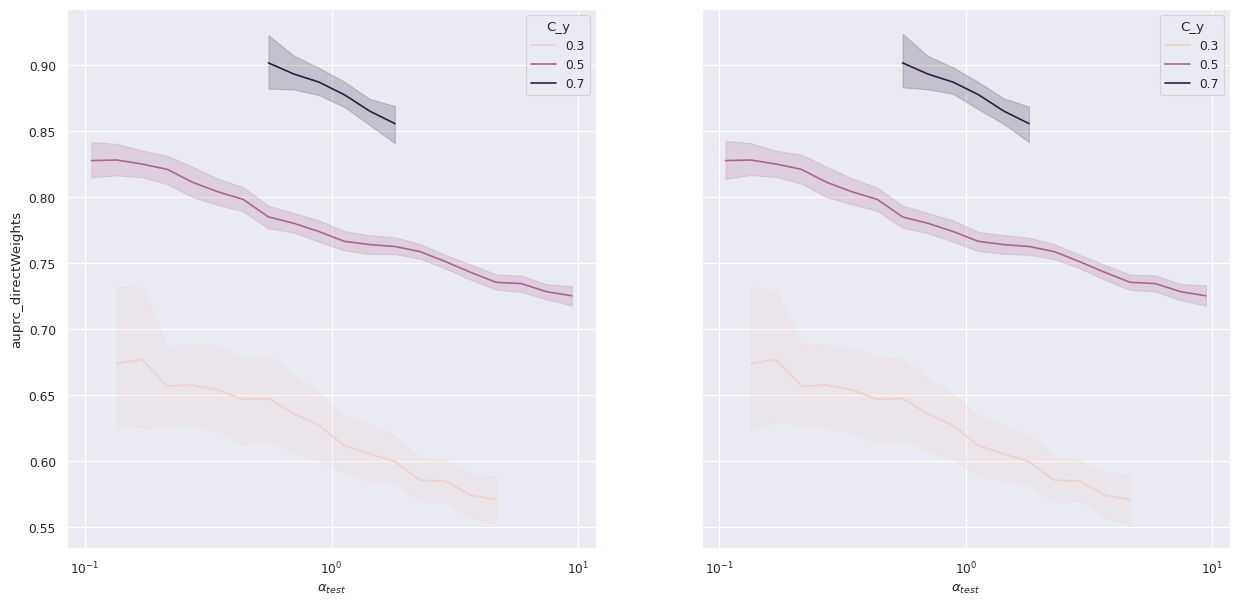

In [18]:
_df_plt = df_eval[df_eval['C_y'].isin([0.3,0.5,0.7])].copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="alpha_test", y="auprc_directWeights", hue='C_y', ax= ax[0])
sns.lineplot(data=_df_plt, x="alpha_test", y="auprc_emWeights", hue='C_y', ax= ax[1])


for i in range(2):
    ax[i].set_xscale('log')
    xlab = r"$\alpha_{test}$"
    ax[i].set_xlabel(xlab)


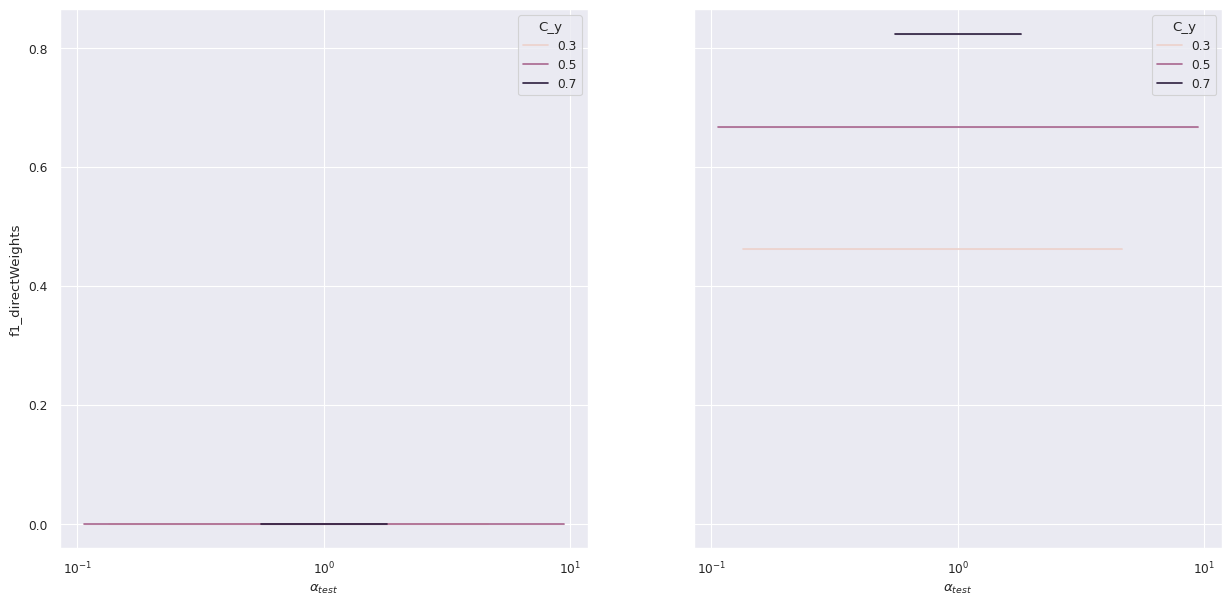

In [19]:
_df_plt = df_eval[df_eval['C_y'].isin([0.3,0.5,0.7])].copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="alpha_test", y="f1_directWeights", hue='C_y', ax= ax[0])
sns.lineplot(data=_df_plt, x="alpha_test", y="f1_emWeights", hue='C_y', ax= ax[1])


for i in range(2):
    ax[i].set_xscale('log')
    xlab = r"$\alpha_{test}$"
    ax[i].set_xlabel(xlab)


Text(0.5, 0, '$\\alpha_{test}$')

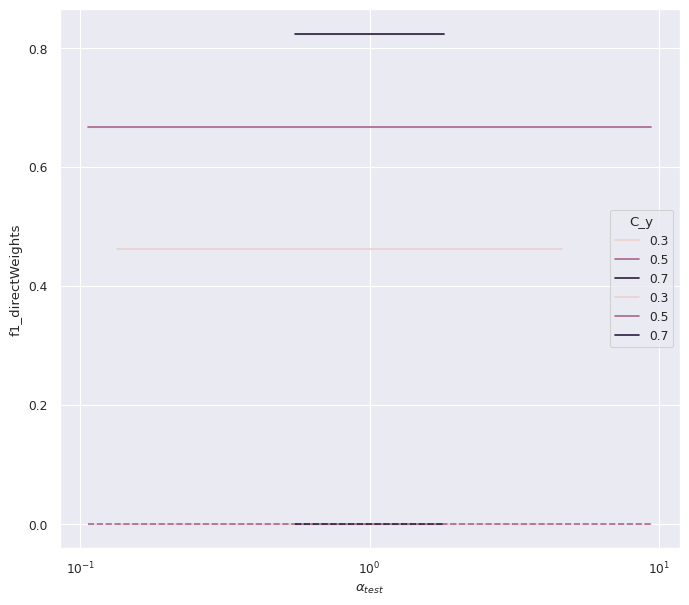

In [20]:
_df_plt = df_eval[df_eval['C_y'].isin([0.3,0.5,0.7])].copy()


fig, ax = plt.subplots(1,1, figsize=(8,7), sharey=True)

sns.lineplot(data=_df_plt, x="alpha_test", y="f1_directWeights", hue='C_y', ax= ax, linestyle='--')
sns.lineplot(data=_df_plt, x="alpha_test", y="f1_emWeights", hue='C_y', ax= ax)


ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlabel(xlab)


<Axes: xlabel='p_pos_test_z0', ylabel='f1_emWeights_df0'>

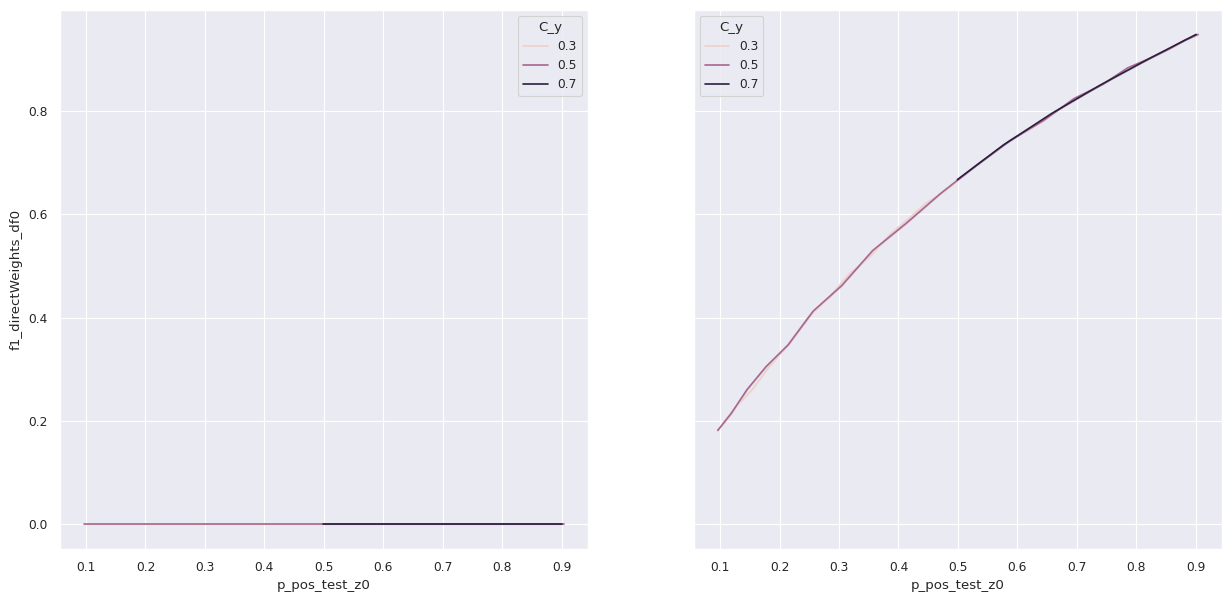

In [21]:
_df_plt = df_eval[df_eval['C_y'].isin([0.3,0.5,0.7])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="p_pos_test_z0", y="f1_directWeights_df0", hue='C_y', ax= ax[0])
sns.lineplot(data=_df_plt, x="p_pos_test_z0", y="f1_emWeights_df0", hue='C_y', ax= ax[1])


# for i in range(2):
#     ax[i].set_xscale('log')
#     xlab = r"$\alpha_{test}$"
#     ax[i].set_xlabel(xlab)


<Axes: xlabel='p_pos_test_z1', ylabel='f1_emWeights_df1'>

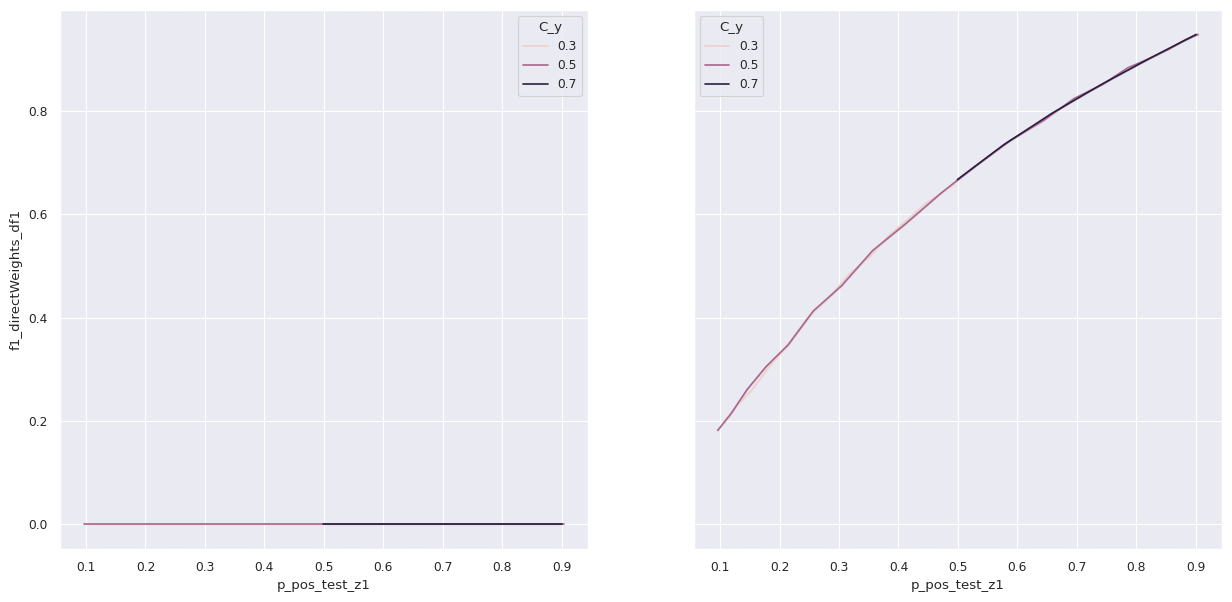

In [22]:
_df_plt = df_eval[df_eval['C_y'].isin([0.3,0.5,0.7])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="p_pos_test_z1", y="f1_directWeights_df1", hue='C_y', ax= ax[0])
sns.lineplot(data=_df_plt, x="p_pos_test_z1", y="f1_emWeights_df1", hue='C_y', ax= ax[1])


# for i in range(2):
#     ax[i].set_xscale('log')
#     xlab = r"$\alpha_{test}$"
#     ax[i].set_xlabel(xlab)


<Axes: xlabel='p_pos_test_z1', ylabel='f1_directWeights_df1'>

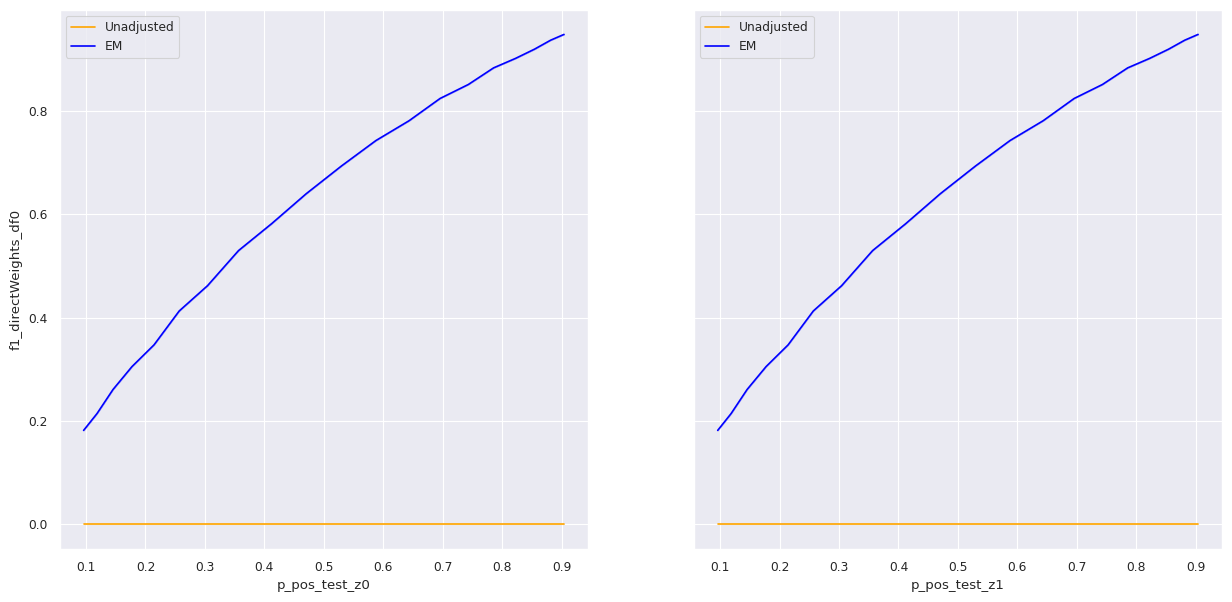

In [31]:
_df_plt = df_eval[df_eval['C_y'].isin([0.5])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="p_pos_test_z0", y="f1_directWeights_df0", c='orange', label="Unadjusted", ax= ax[0])
sns.lineplot(data=_df_plt, x="p_pos_test_z0", y="f1_emWeights_df0", c='blue', label="EM", ax= ax[0])

sns.lineplot(data=_df_plt, x="p_pos_test_z1", y="f1_directWeights_df1", c='orange', label="Unadjusted", ax= ax[1])
sns.lineplot(data=_df_plt, x="p_pos_test_z1", y="f1_emWeights_df1", c='blue', label="EM", ax= ax[1])


# for i in range(2):
#     ax[i].set_xscale('log')
#     xlab = r"$\alpha_{test}$"
#     ax[i].set_xlabel(xlab)


<Axes: xlabel='C_y', ylabel='f1_directWeights_df1'>

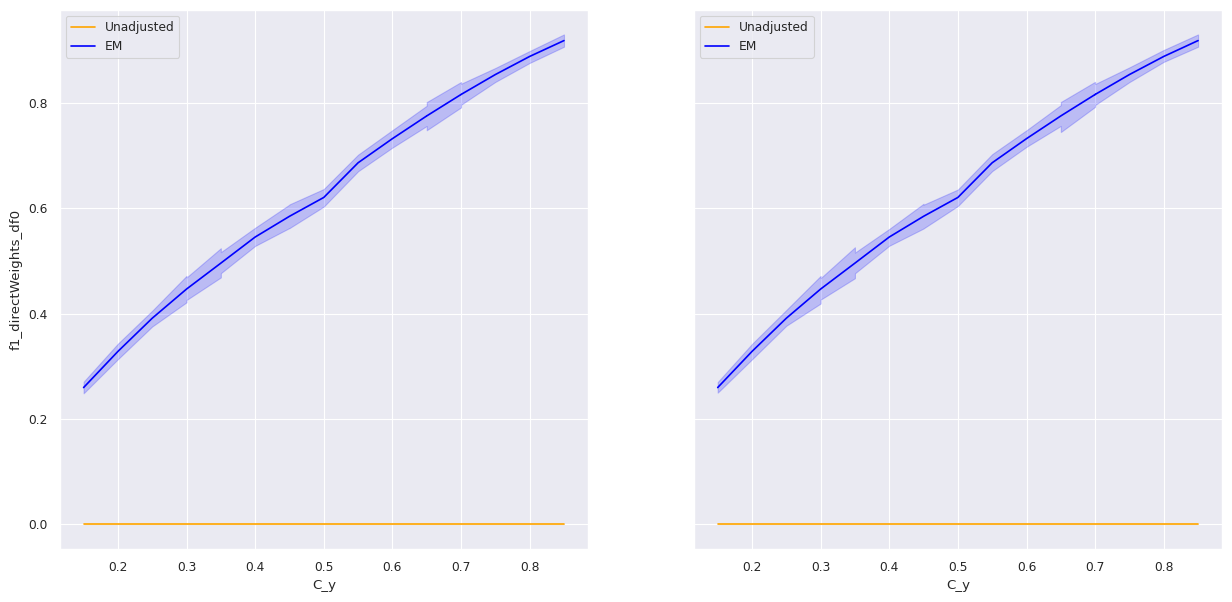

In [38]:
_df_plt = df_eval.query("C_z==0.5").copy()


fig, ax = plt.subplots(1,2, figsize=(15,7), sharey=True)

sns.lineplot(data=_df_plt, x="C_y", y="f1_directWeights_df0", c='orange', label="Unadjusted", ax= ax[0])
sns.lineplot(data=_df_plt, x="C_y", y="f1_emWeights_df0", c='blue', label="EM", ax= ax[0])

sns.lineplot(data=_df_plt, x="C_y", y="f1_directWeights_df1", c='orange', label="Unadjusted", ax= ax[1])
sns.lineplot(data=_df_plt, x="C_y", y="f1_emWeights_df1", c='blue', label="EM", ax= ax[1])


# for i in range(2):
#     ax[i].set_xscale('log')
#     xlab = r"$\alpha_{test}$"
#     ax[i].set_xlabel(xlab)


Text(0.5, 0, '$\\alpha_{test}$')

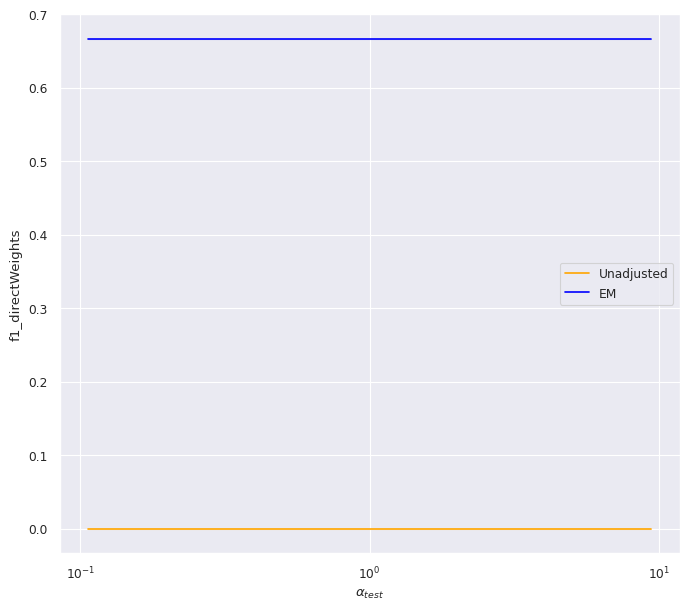

In [24]:
_df_plt = df_eval[df_eval['C_y'].isin([0.5])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,1, figsize=(8,7), sharey=True)

sns.lineplot(data=_df_plt, x="alpha_test", y="f1_directWeights", c='orange', label="Unadjusted", ax= ax)
sns.lineplot(data=_df_plt, x="alpha_test", y="f1_emWeights", c='blue', label="EM", ax= ax)




ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlabel(xlab)


Text(0.5, 0, '$\\alpha_{test}$')

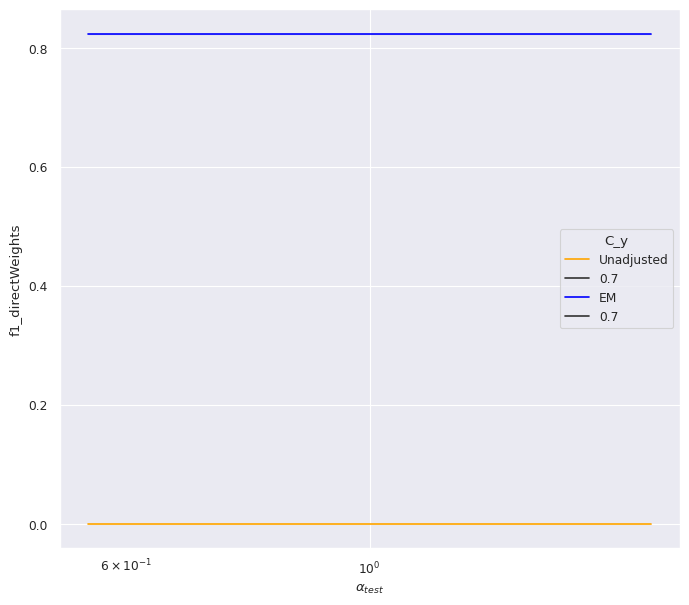

In [37]:
_df_plt = df_eval[df_eval['C_y'].isin([0.7])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,1, figsize=(8,7), sharey=True)


sns.lineplot(data=_df_plt, x="alpha_test", y="f1_directWeights", c='orange', style='C_y', label="Unadjusted", ax= ax)
sns.lineplot(data=_df_plt, x="alpha_test", y="f1_emWeights", style='C_y', c='blue', label="EM", ax= ax)




ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlabel(xlab)


In [32]:
df_eval.columns

Index(['auprc_directWeights', 'auroc_directWeights', 'precision_directWeights',
       'recall_directWeights', 'f1_directWeights', 'calibration_directWeights',
       'auprc_directWeights_df0', 'auroc_directWeights_df0',
       'precision_directWeights_df0', 'recall_directWeights_df0',
       'f1_directWeights_df0', 'calibration_directWeights_df0',
       'auprc_directWeights_df1', 'auroc_directWeights_df1',
       'precision_directWeights_df1', 'recall_directWeights_df1',
       'f1_directWeights_df1', 'calibration_directWeights_df1',
       'auprc_emWeights', 'auroc_emWeights', 'precision_emWeights',
       'recall_emWeights', 'f1_emWeights', 'calibration_emWeights',
       'auprc_emWeights_df0', 'auroc_emWeights_df0', 'precision_emWeights_df0',
       'recall_emWeights_df0', 'f1_emWeights_df0', 'calibration_emWeights_df0',
       'auprc_emWeights_df1', 'auroc_emWeights_df1', 'precision_emWeights_df1',
       'recall_emWeights_df1', 'f1_emWeights_df1', 'calibration_emWeights_df1',
  

Text(0.5, 0, '$\\alpha_{test}$')

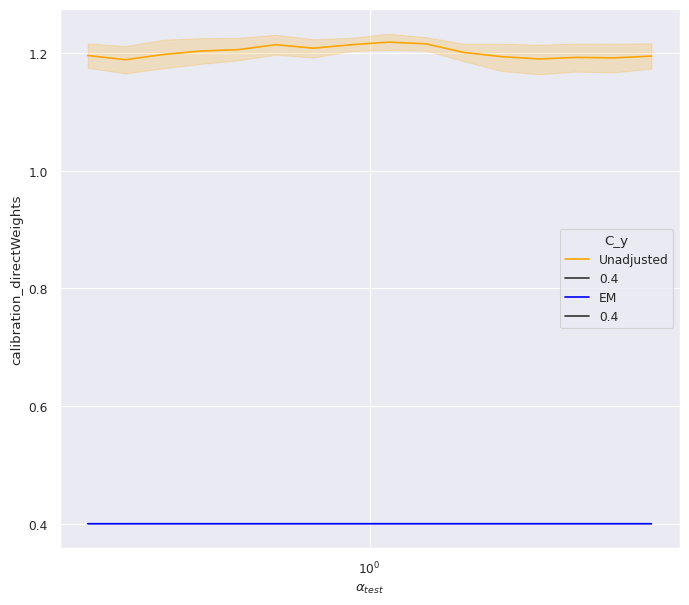

In [36]:
_df_plt = df_eval[df_eval['C_y'].isin([0.4])].query("C_z==0.5").copy()


fig, ax = plt.subplots(1,1, figsize=(8,7), sharey=True)


sns.lineplot(data=_df_plt, x="alpha_test", y="calibration_directWeights", c='orange', style='C_y', label="Unadjusted", ax= ax)
sns.lineplot(data=_df_plt, x="alpha_test", y="calibration_emWeights", style='C_y', c='blue', label="EM", ax= ax)




ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlabel(xlab)


In [26]:
df_eval.groupby("C_y", as_index=False).size().sort_values('size', ascending=False)

,C_y,size
85,0.50,1350
64,0.40,1165
105,0.60,800
39,0.30,705
69,0.42,680
...,...,...
1,0.10,5
40,0.30,5
131,0.71,5
130,0.71,5


In [27]:
# # _df_plt = df_eval[df_eval['C_y'].isin([0.6])].copy()
# _df_plt = df_eval.copy()


# fig, ax = plt.subplots(1,1, figsize=(7,5), sharey=True, )

# sns.lineplot(data=_df_plt, x="alpha_test", y="f1_weightsEdited", c='orange', label="Unadjusted", ax=ax)


# sns.lineplot(data=_df_plt, x="alpha_test", y="f1_emEdited", label="Adjusted", c='blue', ax=ax)
# ax.legend()
# # ax.set_xlim(0.5, 10)
# ax.set_xscale('log')
# xlab = r"$\alpha_{test}$"
# ax.set_xlabel(xlab)
